<p align="left">
  <a href="https://colab.research.google.com/github/wgomezf/ANNs/blob/main/Notebooks/CNN_translearn.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" width="200">
  </a>
</p>

In [ ]:
#####################################################
# Author: Wilfrido Gómez-Flores (Cinvestav)         #
# e-mail: wgomez@cinvestav.mx                       #
# Date:   february 2026                             #
# Subject: Transfer learning for BUS classification #
#####################################################

# Change: Runtime to GPU
# Check GPU details
# !nvidia-smi

# Libraries
import numpy as np                                                    # Numerical array operations
import matplotlib.pyplot as plt                                       # Data plotting/visualization
import tensorflow as tf                                               # Machine learning
import os                                                             # Interaction with the operating system
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import gdown

In [ ]:
# Download BUS.zip dataset
!gdown --id 1BDIbNvvv7W2LYIIPD_SHgyy-J6nEbisy --output BUS.zip

# Unzip BUS.zip file
!unzip -q '/content/BUS.zip' -d '/content/'

# Remove BUS.zip file
!rm '/content/BUS.zip'

# Paths
dataset = 'BUS'
path = '/content/' + dataset + '/'

train_dir = path + 'train/'
val_dir = path + 'valid/'
test_dir = path + 'test/'

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1BDIbNvvv7W2LYIIPD_SHgyy-J6nEbisy
To: /content/BUS.zip
100% 16.1M/16.1M [00:00<00:00, 162MB/s]


In [ ]:
# Prepare training, validation, and test sets
class_mode = 'binary'
batch_size = 32
image_size =  (224, 224)
image_mode = 'rgb'

# Batch generation
data_augmentation = True

# Data augmentation
if data_augmentation:
  train_datagen = ImageDataGenerator(rescale=1.0/255.0,
                                     zoom_range=0.3,
                                     rotation_range=15,
                                     width_shift_range=0.2,
                                     height_shift_range=0.2,
                                     horizontal_flip=True,
                                     vertical_flip=True,
                                     brightness_range=[0.5, 1.5],
                                     fill_mode='constant')
else:
  train_datagen = ImageDataGenerator(rescale=1.0/255.0)

val_datagen = ImageDataGenerator(rescale = 1.0/255.0)
test_datagen = ImageDataGenerator(rescale = 1.0/255.0)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size = image_size,
    batch_size = batch_size,
    color_mode = image_mode,
    class_mode = class_mode,
    shuffle = True)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size = image_size,
    batch_size = batch_size,
    color_mode = image_mode,
    class_mode = class_mode,
    shuffle = False)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size = image_size,
    batch_size = batch_size,
    color_mode = image_mode,
    class_mode = class_mode,
    shuffle = False)

Found 1313 images belonging to 2 classes.
Found 281 images belonging to 2 classes.
Found 281 images belonging to 2 classes.


In [ ]:
# Download pretrained ResNet-50 model on RadImageNet for transfer learning
# https://github.com/BMEII-AI/RadImageNet
# https://doi.org/10.1148/ryai.210315
url='https://drive.google.com/file/d/1dJOAtHAK2gETescvH-A99gmnb0cxz3lV/view?usp=drive_link'
drive_id = url.split('/')[-2]
download_url = 'https://drive.google.com/uc?id=' + drive_id

# Download the model to a local temporary file
model_path = tf.keras.utils.get_file(
    'resnet50.h5',  # Local filename
    origin = download_url, # Remote URL
    extract = False # Set to True if it's a zipped archive that needs extraction
)

base_model = tf.keras.models.load_model(model_path, compile=False) # ResNet-50 backbone

print(f"Model downloaded to: {model_path}")
print("Model loaded successfully!")
base_model.summary() # Show architecture

# Delete model file
!rm /root/.keras/datasets/resnet50.h5

94852768/94852768 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Model downloaded to: /root/.keras/datasets/resnet50.h5
Model loaded successfully!


Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_2             │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_2[0][0]     │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 23,534,592 (89.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [ ]:
# Freeze trainable layers
freeze_all = False

if freeze_all:
  base_model.trainable = False # Freeze all trainable layers
else:
  base_model.trainable = True # Unfreeze all trainable layers
  fine_tune_at = 143 # Freeze until conv4 block
  for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False # Freeze some trainable layers

# Layers of the base model
for i, layer in enumerate(base_model.layers[:]):
  print(f'{i}: {layer.name}, {layer.trainable}')

0: input_2, False
1: conv1_pad, False
2: conv1_conv, False
3: conv1_bn, False
4: conv1_relu, False
5: pool1_pad, False
6: pool1_pool, False
7: conv2_block1_1_conv, False
8: conv2_block1_1_bn, False
9: conv2_block1_1_relu, False
10: conv2_block1_2_conv, False
11: conv2_block1_2_bn, False
12: conv2_block1_2_relu, False
13: conv2_block1_0_conv, False
14: conv2_block1_3_conv, False
15: conv2_block1_0_bn, False
16: conv2_block1_3_bn, False
17: conv2_block1_add, False
18: conv2_block1_out, False
19: conv2_block2_1_conv, False
20: conv2_block2_1_bn, False
21: conv2_block2_1_relu, False
22: conv2_block2_2_conv, False
23: conv2_block2_2_bn, False
24: conv2_block2_2_relu, False
25: conv2_block2_3_conv, False
26: conv2_block2_3_bn, False
27: conv2_block2_add, False
28: conv2_block2_out, False
29: conv2_block3_1_conv, False
30: conv2_block3_1_bn, False
31: conv2_block3_1_relu, False
32: conv2_block3_2_conv, False
33: conv2_block3_2_bn, False
34: conv2_block3_2_relu, False
35: conv2_block3_3_conv, 

In [ ]:
# Assembling model with new output
x = base_model.output # ResNet-50
x = tf.keras.layers.GlobalAveragePooling2D()(x) # Flatten with GAP
output = tf.keras.layers.Dense(1, activation = 'sigmoid')(x) # Output
model = tf.keras.Model(inputs=base_model.input, outputs=output)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_2             │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_2[0][0]     │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 14,978,049 (57.14 MB)

 Non-trainable params: 8,611,712 (32.85 MB)

In [ ]:
# Compile model
adam = tf.keras.optimizers.Adam(learning_rate=1e-3)
model.compile(loss='binary_crossentropy', optimizer=adam, metrics=['auc'])

# Callbacks
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_auc',
    patience=10,
    mode='max',
    restore_best_weights=True
) # Early stopping

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_auc',
    factor=0.25,
    patience=5,
    min_lr=1e-6,
    verbose=1
) # Learning rate schedule

# Train model
epochs = 50
history = model.fit(train_generator,
                    batch_size=batch_size,
                    epochs=epochs,
                    validation_data=(val_generator),
                    verbose=1,
                    callbacks=[early_stop, reduce_lr])

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 50s 718ms/step - auc: 0.6792 - loss: 0.6372 - val_auc: 0.8057 - val_loss: 0.5249 - learning_rate: 0.0010
Epoch 2/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 15s 364ms/step - auc: 0.7836 - loss: 0.5386 - val_auc: 0.8049 - val_loss: 0.6479 - learning_rate: 0.0010
Epoch 3/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 15s 367ms/step - auc: 0.8059 - loss: 0.5354 - val_auc: 0.8069 - val_loss: 0.5166 - learning_rate: 0.0010
Epoch 4/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 15s 367ms/step - auc: 0.8391 - loss: 0.4575 - val_auc: 0.8194 - val_loss: 0.5218 - learning_rate: 0.0010
Epoch 5/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 15s 364ms/step - auc: 0.8311 - loss: 0.4676 - val_auc: 0.8084 - val_loss: 0.8567 - learning_rate: 0.0010
Epoch 6/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 15s 367ms/step - auc: 0.8336 - loss: 0.4732 - val_auc: 0.8523 - val_loss: 0.4311 - learning_rate: 0.0010
Epoch 7/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step - auc: 0.8524 - loss: 0.4474
Epoch 7: ReduceLROnPlateau reducing learning rate to 0.000250

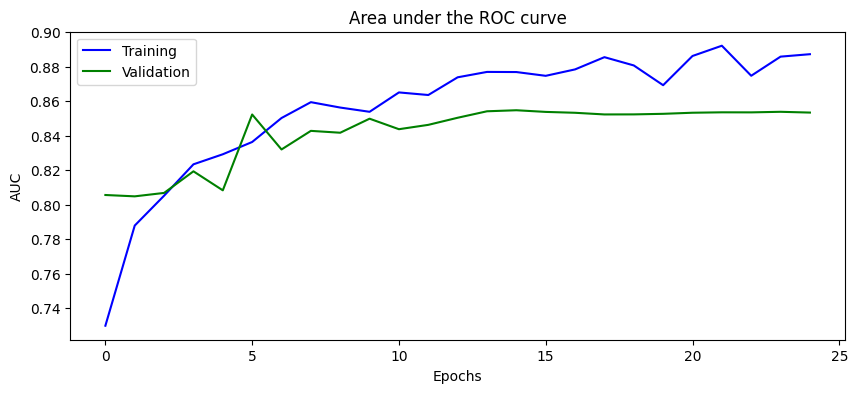

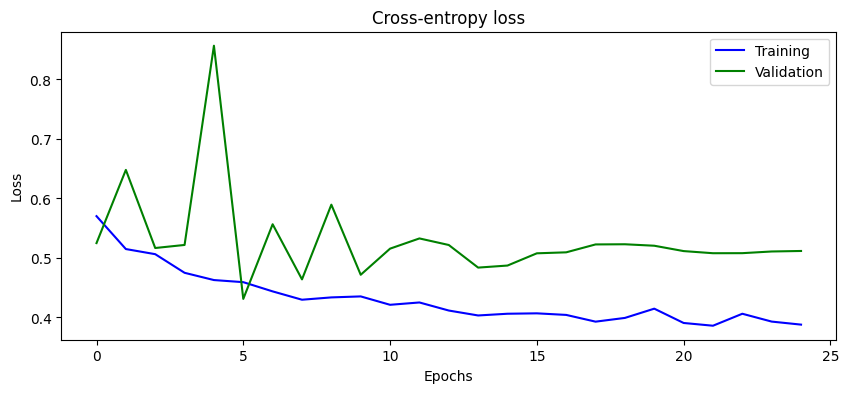

In [ ]:
# Training and validation graphs
training_acc = history.history['auc']
validation_acc = history.history['val_auc']
training_loss = history.history['loss']
validation_loss = history.history['val_loss']
epocas = np.arange(len(training_loss))

plt.figure(figsize=(10, 4))
plt.plot(epocas, training_acc, color='blue', label='Training')
plt.plot(epocas, validation_acc, color = 'green', label='Validation')
plt.title('Area under the ROC curve')
plt.xlabel('Epochs')
plt.ylabel('AUC')
plt.legend()
plt.show()
print()

plt.figure(figsize = (10, 4))
plt.plot(epocas, training_loss, color='blue', label='Training')
plt.plot(epocas, validation_loss, color = 'green', label='Validation')
plt.title('Cross-entropy loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

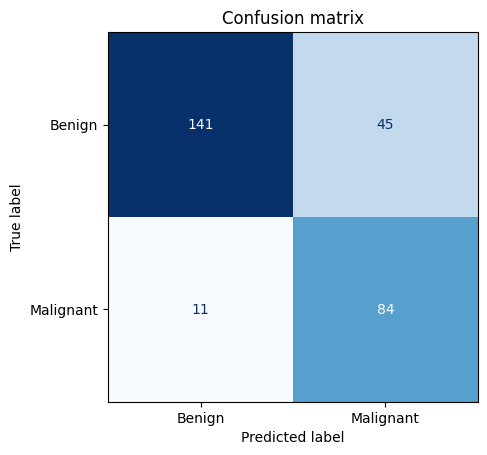

Accuracy: 0.801 

Sensitivity: 0.884 

Specificity: 0.758 



In [ ]:
# Get true labels and predictions from test set
test_generator.reset()
Y_true  = test_generator.labels
Y_true = Y_true.reshape(-1, 1)
Y_probs = model.predict(test_generator, verbose = 0)
Y_pred  = np.round(Y_probs)

# Confusion matrix
cm = confusion_matrix(Y_true, Y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign', 'Malignant'])
disp.plot(colorbar=False, cmap='Blues')
plt.title('Confusion matrix')
plt.show()

# Performance indices
tn, fp, fn, tp = confusion_matrix(Y_true, Y_pred).ravel()
acc = (tp + tn) / (tp + tn + fp + fn)
sen = tp / (tp + fn)
spe = tn / (tn + fp)
print(f"Accuracy: {acc:.3f} \n")
print(f"Sensitivity: {sen:.3f} \n")
print(f"Specificity: {spe:.3f} \n")

In [ ]:
# # Uncomment these lines to perform the following tasks:
# # Save CNN model i Google drive
# from google.colab import drive
# drive.mount('/content/drive')
# model.save('/content/drive/MyDrive/bus_resnet50.keras')